## Лабораторна робота 6: RNN vs LSTM for Fake News Classification
**Мета роботи:** реалізація, навчання та порівняльний аналіз двох архітектур нейронних мереж - рекурентної нейронної мережі (RNN) та мережі з довгостроковою короткостроковою памʼяттю (LSTM) - для задачі бінарної класифікації текстів новин на фейкові та справжні.

**Завдання:**
- розробити повний пайплайн обробки текстових даних для задачі класифікації
- реалізувати архітектури RNN та LSTM з використанням PyTorch
- провести експериментальне дослідження впливу різних архітектурних рішень
- порівняти ефективність моделей за метриками точності, стабільності та швидкості навчання
- зробити висновки щодо оптимального вибору архітектури для аналізу текстів новин

### Вміст роботи
У цій лабораторній роботі виконується практична реалізація та порівняння нейронних мереж для класифікації фейкових новин. 

**Основні етапи:**
1. Підготовка даних 
- завантаження та маркування датасетів фейкових та справжніх новин 
- очищення текстів, токенізація та паддінг 
- розподіл на train/val/test 

2. Реалізація моделей
- Simple RNN: базова рекурентна архітектура 
- LSTM: покращена версія з бідирекційною обробкою 
- Embedding шари, dropout регуляризація

3. Навчання та оцінка 
- навчання з використанням BCEWithLogitsLoss та Adam оптимізатора 
- обчислення метрик: accuracy, precision, recall, F1, AUC
- візуалізація: ROC-криві, матриці плутанини, графіки навчання 

4. Порівняльний аналіз 
- RNN: швидше навчання, обмеження в обробці довгих текстів
- LSTM: краща точність та стабільність 
- Практичні рекомендації щодо вибору архітектури

Робота демонструє повний цикл розробки системи машинного навчання від підготовки даних до оцінки результатів.

### Імпорт необхідних бібліотек та встановлення даних

In [1]:
# комірка 1
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import re
import nltk
import ssl
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
from tabulate import tabulate

# Встановлення насіння для відтворюваності результатів
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print("✅ Бібліотеки успішно імпортовано")
print(f"🔢 Насіння для відтворюваності: {SEED}")

✅ Бібліотеки успішно імпортовано
🔢 Насіння для відтворюваності: 42


### Налаштування бібліотеки NLTK для обробки природної мови
Налаштування SSL зʼєднання, автоматичне налаштування NLTK, імпорт основних функцій NLTK

In [2]:
# комірка 2
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

def setup_nltk_complete():
    """Повне налаштування NLTK з усіма необхідними ресурсами"""
    print("\n" + "="*70)
    print("🔧 ПОВНЕ НАЛАШТУВАННЯ NLTK")
    print("="*70)
    
    # Список всіх можливих шляхів до даних NLTK
    print("🔍 Пошук шляхів до nltk_data...")
    possible_paths = [
        'nltk_data',
        os.path.expanduser('~/nltk_data'),
        os.path.expanduser('~/nltk'),
        '/usr/share/nltk_data',
        '/usr/local/share/nltk_data',
        '/usr/lib/nltk_data',
        '/usr/local/lib/nltk_data'
    ]
    
    # Додавання всіх знайдених шляхів до nltk.data.path
    found_paths = []
    for path in possible_paths:
        if os.path.exists(path):
            nltk.data.path.append(path)
            found_paths.append(path)
    
    if found_paths:
        print(f"✅ Знайдено {len(found_paths)} шляхів до nltk_data")
        for path in found_paths:
            print(f"  📁 {path}")
    else:
        print("⚠️  Шляхи до nltk_data не знайдено")
    
    # Всі необхідні ресурси для токенізації
    required_resources = [
        'punkt',
        'punkt_tab',
        'stopwords',
        'averaged_perceptron_tagger',
        'wordnet',
        'omw-eng'
    ]
    
    print("\n📥 Перевірка та завантаження ресурсів NLTK...")
    for resource in required_resources:
        try:
            if resource == 'punkt':
                nltk.data.find('tokenizers/punkt')
            elif resource == 'punkt_tab':
                nltk.data.find('tokenizers/punkt_tab')
            elif resource == 'stopwords':
                nltk.data.find('corpora/stopwords')
            elif resource == 'averaged_perceptron_tagger':
                nltk.data.find('taggers/averaged_perceptron_tagger')
            elif resource == 'wordnet':
                nltk.data.find('corpora/wordnet')
            elif resource == 'omw-eng':
                nltk.data.find('corpora/omw')
            
            print(f"  ✅ {resource} знайдено")
            
        except LookupError:
            print(f"  ⬇️  Завантаження {resource}...")
            try:
                nltk.download(resource, quiet=True)
                print(f"    ✅ {resource} успішно завантажено")
            except Exception as e:
                print(f"    ⚠️  Не вдалося завантажити {resource}: {e}")
                if resource == 'punkt_tab':
                    print(f"    🔄 Спробую завантажити punkt замість punkt_tab...")
                    try:
                        nltk.download('punkt', quiet=True)
                        print(f"      ✅ punkt завантажено як альтернатива")
                    except:
                        print(f"      ❌ Не вдалося завантажити punkt")
    
    print("\n" + "="*70)
    print("✅ НАЛАШТУВАННЯ NLTK УСПІШНО ЗАВЕРШЕНО")
    print("="*70)

# Запуск повного налаштування NLTK
setup_nltk_complete()

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords


🔧 ПОВНЕ НАЛАШТУВАННЯ NLTK
🔍 Пошук шляхів до nltk_data...
✅ Знайдено 1 шляхів до nltk_data
  📁 /Users/fannciful/nltk_data

📥 Перевірка та завантаження ресурсів NLTK...
  ✅ punkt знайдено
  ✅ punkt_tab знайдено
  ✅ stopwords знайдено
  ✅ averaged_perceptron_tagger знайдено
  ⬇️  Завантаження wordnet...
    ✅ wordnet успішно завантажено
  ⬇️  Завантаження omw-eng...
    ✅ omw-eng успішно завантажено

✅ НАЛАШТУВАННЯ NLTK УСПІШНО ЗАВЕРШЕНО


[nltk_data] Error loading omw-eng: Package 'omw-eng' not found in
[nltk_data]     index


### Реалізація власного токенізатора тексту 
Створення класу SimpleTokenizer для обробки текстових даних без залежності від зовнішніх бібліотек. Включає ініціалізацію стоп-слів, очищення тексту та токенізацію, з наступним текстуванням функціональності.

In [3]:
# комірка 3
class SimpleTokenizer:
    """Простий та надійний токенізатор без залежності від NLTK"""
    
    def __init__(self):
        # Комплексний список англійських стоп-слів
        self.stop_words = {
            'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 
            'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 
            'her', 'hers', 'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 
            'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', 
            'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 
            'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 
            'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 
            'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 
            'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 
            'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once',
            'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 
            'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 
            'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 
            'don', 'should', 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', 
            'couldn', 'didn', 'doesn', 'hadn', 'hasn', 'haven', 'isn', 'ma', 'mightn', 
            'mustn', 'needn', 'shan', 'shouldn', 'wasn', 'weren', 'won', 'wouldn'
        }
        print(f"✅ Ініціалізовано {len(self.stop_words)} стоп-слів")
    
    def clean_text(self, text):
        """Очищення тексту без NLTK"""
        if not isinstance(text, str) or pd.isna(text):
            return ""
        
        text = str(text).lower()
        # Видалення URL
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
        # Видалення HTML тегів
        text = re.sub(r'<.*?>', '', text)
        # Видалення облікових записів Twitter та хештегів
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#\w+', '', text)
        # Видалення спеціальних символів, збереження апострофів
        text = re.sub(r"[^\w\s']", ' ', text)
        # Видалення цифр
        text = re.sub(r'\d+', '', text)
        # Видалення зайвих пробілів
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    
    def tokenize(self, text):
        """Проста токенізація без NLTK"""
        text = self.clean_text(text)
        if not text:
            return []
        
        # Простий розділ за пробілами
        tokens = text.split()
        
        # Видалення стоп-слів та коротких токенів
        tokens = [token for token in tokens 
                 if token not in self.stop_words and len(token) > 2]
        
        return tokens

# Ініціалізація простого токенізатора
print("\n" + "="*70)
print("🔤 ІНІЦІАЛІЗАЦІЯ ТОКЕНІЗАТОРА")
print("="*70)
simple_tokenizer = SimpleTokenizer()

# Тест токенізатора
test_text = "Hello world! This is a test of the simple tokenizer."
tokens = simple_tokenizer.tokenize(test_text)
print(f"\n🧪 Тест токенізації: '{test_text}'")
print(f"📊 Результат: {tokens}")
print("="*70)
print("✅ ТОКЕНІЗАТОР УСПІШНО НАЛАШТОВАНО")
print("="*70)


🔤 ІНІЦІАЛІЗАЦІЯ ТОКЕНІЗАТОРА
✅ Ініціалізовано 153 стоп-слів

🧪 Тест токенізації: 'Hello world! This is a test of the simple tokenizer.'
📊 Результат: ['hello', 'world', 'test', 'simple', 'tokenizer']
✅ ТОКЕНІЗАТОР УСПІШНО НАЛАШТОВАНО


### Створення класів для обробки текстових даних 
Реалізація спеціалізованих класів для роботи з текстовими даними у PyTorch. Клас NewsDataset забезпечує інтерфейс для завантаження статей новин, а TextProcessor відповідає за попередню обробку тексту та побудову словника.

In [4]:
# комірка 4
class NewsDataset(Dataset):
    """PyTorch Dataset для статей новин з використанням простого токенізатора"""
    
    def __init__(self, texts, labels, vocab, max_length=200):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # Конвертація тексту в індекси за допомогою простого токенізатора
        tokens = simple_tokenizer.tokenize(text)[:self.max_length]
        indices = [self.vocab.get(token, self.vocab['<UNK>']) for token in tokens]
        
        # Доповнення або усічення
        if len(indices) < self.max_length:
            indices = indices + [self.vocab['<PAD>']] * (self.max_length - len(indices))
        else:
            indices = indices[:self.max_length]
        
        return torch.tensor(indices), torch.tensor(label, dtype=torch.float32)


class TextPreprocessor:
    """Попередня обробка тексту з простим токенізатором"""
    
    def __init__(self, max_vocab_size=10000, max_length=200):
        self.vocab = {}
        self.inverse_vocab = {}
        self.max_vocab_size = max_vocab_size
        self.max_length = max_length
        
    def build_vocab(self, texts):
        """Побудова словника з текстів за допомогою простого токенізатора"""
        all_tokens = []
        
        print(f"\n📚 Побудова словника з {len(texts):,} текстів...")
        
        for i, text in enumerate(texts):
            tokens = simple_tokenizer.tokenize(text)
            all_tokens.extend(tokens)
            
            # Відображення прогресу кожні 1000 текстів
            if (i + 1) % 1000 == 0:
                print(f"  📈 Оброблено {i + 1:,}/{len(texts):,} текстів...")
        
        if not all_tokens:
            print("⚠️  Попередження: Жодних токенів не знайдено!")
            all_tokens = ['news', 'fake', 'real', 'trump', 'said']  # Токени за замовчуванням
        
        # Підрахунок частот слів
        word_counts = Counter(all_tokens)
        most_common = word_counts.most_common(self.max_vocab_size - 4)
        
        # Створення словника зі спеціальними токенами
        self.vocab = {
            '<PAD>': 0,    # Токен для доповнення
            '<UNK>': 1,    # Токен для невідомих слів
            '<START>': 2,  # Токен початку послідовності
            '<END>': 3     # Токен кінця послідовності
        }
        
        for idx, (word, _) in enumerate(most_common):
            self.vocab[word] = idx + 4
        
        self.inverse_vocab = {idx: word for word, idx in self.vocab.items()}
        
        # Показ статистики словника
        print(f"\n📊 Статистика словника:")
        print(f"  ├─ Унікальних токенів: {len(set(all_tokens)):,}")
        print(f"  ├─ Загальна кількість токенів: {len(all_tokens):,}")
        print(f"  └─ Розмір словника: {len(self.vocab):,}")
        
        # Показ найчастіших слів
        print(f"\n🏆 Топ-10 найчастіших слів:")
        for i, (word, count) in enumerate(word_counts.most_common(10), 1):
            print(f"  {i:2}. {word:15} {count:,}")
        
        return self.vocab

print("\n" + "="*70)
print("✅ КЛАСИ ДЛЯ ОБРОБКИ ДАНИХ УСПІШНО СТВОРЕНО")
print("="*70)



✅ КЛАСИ ДЛЯ ОБРОБКИ ДАНИХ УСПІШНО СТВОРЕНО


### Визначення архітектур нейронних мереж RNN та LSTM
Реалізація двох основних класів нейронних мереж для класифікації текстів: SimpleRNNClassifier та LSTMClassifier. Кожен клас включає embedding шар для перетворення токенів у вектори, рекурентний шар для обробки послідовностей, dropout для регуляризації та лінійний класифікатор для бінарної класифікації. LSTM має додаткову можливість бідирекційної обробки для кращого розуміння контексту.

In [5]:
# комірка 5
class SimpleRNNClassifier(nn.Module):
    """
    Простий RNN класифікатор як визначено у Завданні Частина A
    
    Математичні формули RNN:
    1. Прихований стан: h_t = tanh(W_ih * x_t + W_hh * h_{t-1} + b_h)
    2. Вихід: o = W_ho * h_T + b_o
    3. Імовірність: p̂ = σ(o)
    """
    
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        
        # RNN шар (Elman-type) з активацією tanh
        self.rnn = nn.RNN(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',
            dropout=(dropout if num_layers > 1 else 0.0)
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)  # Вихід для бінарної класифікації
        
    def forward(self, x):
        # Прямий прохід відповідно до формул: h_t = tanh(W_ih x_t + W_hh h_{t-1} + b_h)
        emb = self.embedding(x)
        out, h_n = self.rnn(emb)
        
        # Використання останнього прихованого стану: o = W_ho h_T + b_o
        last_hidden = h_n[-1]
        last_hidden = self.dropout(last_hidden)
        logits = self.fc(last_hidden).squeeze(1)
        
        # Імовірність: p̂ = σ(o)
        return torch.sigmoid(logits), logits


class LSTMClassifier(nn.Module):
    """
    LSTM класифікатор з опцією бідирекційності
    
    Математичні формули LSTM:
    1. Забуваюча затворка: f_t = σ(W_f * [h_{t-1}, x_t] + b_f)
    2. Вхідна затворка: i_t = σ(W_i * [h_{t-1}, x_t] + b_i)
    3. Кандидат на оновлення: g_t = tanh(W_g * [h_{t-1}, x_t] + b_g)
    4. Оновлення стану комірки: c_t = f_t * c_{t-1} + i_t * g_t
    5. Вихідна затворка: o_t = σ(W_o * [h_{t-1}, x_t] + b_o)
    6. Оновлення прихованого стану: h_t = o_t * tanh(c_t)
    """
    
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, 
                 bidirectional=False, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        
        # LSTM шар з усіма затворками як визначено у Частині A
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=(dropout if num_layers > 1 else 0.0)
        )
        
        self.bidirectional = bidirectional
        factor = 2 if bidirectional else 1
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * factor, 1)
        
    def forward(self, x):
        # Прямий прохід LSTM з усіма затворками
        emb = self.embedding(x)
        out, (h_n, c_n) = self.lstm(emb)
        
        # Обробка бідирекційного випадку
        if self.bidirectional:
            last_hidden = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            last_hidden = h_n[-1]
        
        last_hidden = self.dropout(last_hidden)
        logits = self.fc(last_hidden).squeeze(1)
        
        return torch.sigmoid(logits), logits

print("\n" + "="*70)
print("✅ АРХІТЕКТУРИ МОДЕЛЕЙ RNN ТА LSTM ВИЗНАЧЕНО")
print("="*70)


✅ АРХІТЕКТУРИ МОДЕЛЕЙ RNN ТА LSTM ВИЗНАЧЕНО


### Функція для завантаження та підготовки даних 
Реалізація функцій для роботи з датасетом новин. load_and_preprocess_data відповідає за завантаження CSV-файлів, обʼєднання фейкових та справжніх новин, маркування класів та розподіл на тренувальні, валідаційні та тестові набори. create_dataloaders створює словник токенів, перетворює тексти в числові послідовності та формує DataLoader-и для ефективного батчового навчання моделей.

In [6]:
# комірка 6
def load_and_preprocess_data(fake_path='Fake.csv', true_path='True.csv', 
                            sample_size=2000, test_size=0.2, val_size=0.1):
    """Завантаження та попередня обробка реального набору даних"""
    
    print("\n" + "="*70)
    print("📥 ЗАВАНТАЖЕННЯ ТА ОБРОБКА ДАНИХ")
    print("="*70)
    
    try:
        # Завантаження CSV файлів
        fake_df = pd.read_csv(fake_path)
        true_df = pd.read_csv(true_path)
        
        print(f"✅ Файли успішно завантажено")
        print(f"  ├─ Фейкові новини: {len(fake_df):,} статей")
        print(f"  └─ Справжні новини: {len(true_df):,} статей")
        
        # Вибірка даних за потреби
        if sample_size:
            print(f"\n🎯 Вибірка {sample_size} статей з кожної категорії...")
            fake_df = fake_df.sample(min(sample_size, len(fake_df)), random_state=SEED)
            true_df = true_df.sample(min(sample_size, len(true_df)), random_state=SEED)
        
    except Exception as e:
        print(f"❌ Помилка завантаження файлів: {e}")
        print("📁 Будь ласка, переконайтесь, що Fake.csv та True.csv знаходяться в поточній директорії")
        return None, None, None
    
    # Додавання міток
    fake_df['label'] = 1  # Фейкові новини
    true_df['label'] = 0  # Справжні новини
    
    # Об'єднання наборів даних
    df = pd.concat([fake_df, true_df], ignore_index=True)
    
    # Перемішування
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    
    # Використання Заголовок + Текст як визначено у завданні
    df['content'] = df['title'] + ' ' + df['text']
    
    print(f"\n📊 Статистика датасету:")
    print(f"  ├─ Загальний розмір: {len(df):,}")
    print(f"  ├─ Фейкові новини: {(df['label'] == 1).sum():,}")
    print(f"  └─ Справжні новини: {(df['label'] == 0).sum():,}")
    
    # Перевірка на відсутні значення
    print(f"\n🔍 Перевірка відсутніх значень...")
    print(f"  ├─ Відсутні заголовки: {df['title'].isna().sum()}")
    print(f"  └─ Відсутній текст: {df['text'].isna().sum()}")
    
    # Видалення рядків з відсутнім контентом
    df = df.dropna(subset=['content'])
    
    # Розподіл даних відповідно до вимог завдання
    print(f"\n📈 Розподіл даних:")
    print(f"  ├─ Навчання: {int((1-test_size-val_size)*100)}%")
    print(f"  ├─ Валідація: {int(val_size*100)}%")
    print(f"  └─ Тест: {int(test_size*100)}%")
    
    if len(df) < 100:  # Обробка маленького датасету
        train_df, temp_df = train_test_split(df, test_size=test_size + val_size, random_state=SEED)
        val_df, test_df = train_test_split(temp_df, test_size=test_size/(test_size + val_size), random_state=SEED)
    else:
        train_df, temp_df = train_test_split(df, test_size=test_size + val_size, 
                                             random_state=SEED, stratify=df['label'])
        val_df, test_df = train_test_split(temp_df, test_size=test_size/(test_size + val_size), 
                                          random_state=SEED, stratify=temp_df['label'])
    
    print(f"\n✅ Фінальний розподіл:")
    print(f"  ├─ Навчання: {len(train_df):,} зразків")
    print(f"  ├─ Валідація: {len(val_df):,} зразків")
    print(f"  └─ Тест: {len(test_df):,} зразків")
    
    return train_df, val_df, test_df


def create_dataloaders(train_df, val_df, test_df, batch_size=32, max_length=200):
    """Створення завантажувачів даних з токенізацією"""
    
    # Ініціалізація попереднього обробника
    preprocessor = TextPreprocessor(max_vocab_size=20000, max_length=max_length)
    
    # Побудова словника з тренувальних даних
    print("\n" + "="*70)
    print("🔠 ПОБУДОВА СЛОВНИКА")
    print("="*70)
    
    start_time = time.time()
    vocab = preprocessor.build_vocab(train_df['content'].tolist())
    vocab_time = time.time() - start_time
    
    print(f"\n⏱️ Час побудови словника: {vocab_time:.2f} секунд")
    print(f"📏 Розмір словника: {len(vocab):,}")
    
    # Показ найчастіших слів
    print("\n🏆 Топ-20 найчастіших слів:")
    word_counts = Counter()
    for text in train_df['content'].tolist():
        tokens = simple_tokenizer.tokenize(text) 
        word_counts.update(tokens)
    
    for i, (word, count) in enumerate(word_counts.most_common(20), 1):
        print(f"  {i:2}. {word:15} {count:,}")
    
    # Показ покриття словника
    total_tokens = sum(word_counts.values())
    top_10000 = sum(count for _, count in word_counts.most_common(10000))
    coverage = (top_10000 / total_tokens * 100) if total_tokens > 0 else 0
    print(f"\n📊 Покриття 10,000 найчастіших слів: {coverage:.2f}%")
    
    # Створення наборів даних
    print("\n📁 Створення наборів даних...")
    train_dataset = NewsDataset(
        train_df['content'].tolist(),
        train_df['label'].tolist(),
        vocab,
        max_length
    )
    
    val_dataset = NewsDataset(
        val_df['content'].tolist(),
        val_df['label'].tolist(),
        vocab,
        max_length
    )
    
    test_dataset = NewsDataset(
        test_df['content'].tolist(),
        test_df['label'].tolist(),
        vocab,
        max_length
    )
    
    # Створення завантажувачів даних
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"\n✅ Завантажувачі даних створено:")
    print(f"  ├─ Навчання: {len(train_loader)} пакетів")
    print(f"  ├─ Валідація: {len(val_loader)} пакетів")
    print(f"  └─ Тест: {len(test_loader)} пакетів")
    
    return train_loader, val_loader, test_loader, len(vocab)

print("\n" + "="*70)
print("✅ ФУНКЦІЇ ЗАВАНТАЖЕННЯ ТА ОБРОБКИ ДАНИХ ВИЗНАЧЕНО")
print("="*70)



✅ ФУНКЦІЇ ЗАВАНТАЖЕННЯ ТА ОБРОБКИ ДАНИХ ВИЗНАЧЕНО


### Реалізація класів для тренування та візуалізації моделей
Створення класу Trainer для інкапсуляції логіки навчання та оцінки нейронних мереж, що включає методи train_epoch для тренування протягом однієї епохи та evaluate для комплексної оцінки продуктивності моделі з розрахунком основних метрик. Клас Visualizer забезпечує візуалізацію результатів через побудову графіків навчання, матриць плутанини та ROC-кривих для наочної інтерпретації результатів класифікації.

In [7]:
# комірка 7
class Trainer:
    """Обробка навчання та оцінки моделей"""
    
    def __init__(self, model, device='cpu'):
        self.model = model.to(device)
        self.device = device
        
    def train_epoch(self, train_loader, criterion, optimizer):
        """Навчання протягом однієї епохи"""
        self.model.train()
        total_loss = 0
        all_preds = []
        all_labels = []
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
            
            optimizer.zero_grad()
            probs, logits = self.model(batch_x)
            
            loss = criterion(logits, batch_y)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 5.0)
            optimizer.step()
            
            total_loss += loss.item()
            preds = (probs > 0.5).float()
            
            all_preds.extend(preds.cpu().detach().numpy())
            all_labels.extend(batch_y.cpu().detach().numpy())
        
        avg_loss = total_loss / len(train_loader)
        accuracy = accuracy_score(all_labels, all_preds)
        
        return avg_loss, accuracy
    
    def evaluate(self, data_loader, criterion):
        """Оцінка продуктивності моделі"""
        self.model.eval()
        total_loss = 0
        all_probs = []
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch_x, batch_y in data_loader:
                batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                
                probs, logits = self.model(batch_x)
                loss = criterion(logits, batch_y)
                
                total_loss += loss.item()
                preds = (probs > 0.5).float()
                
                all_probs.extend(probs.cpu().detach().numpy())
                all_preds.extend(preds.cpu().detach().numpy())
                all_labels.extend(batch_y.cpu().detach().numpy())
        
        avg_loss = total_loss / len(data_loader)
        
        # Обчислення всіх необхідних метрик
        accuracy = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, zero_division=0)
        recall = recall_score(all_labels, all_preds, zero_division=0)
        f1 = f1_score(all_labels, all_preds, zero_division=0)
        roc_auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.5
        
        return {
            'loss': avg_loss,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'probs': all_probs,
            'preds': all_preds,
            'labels': all_labels
        }


class Visualizer:
    """Обробка всіх візуалізацій для завдання"""
    
    @staticmethod
    def plot_training_history(train_losses, val_losses, train_accs, val_accs, model_name):
        """Побудова графіків навчання та валідації"""
        plt.style.use('seaborn-v0_8-darkgrid')
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Графік втрат
        axes[0].plot(train_losses, label='Навчання', linewidth=2.5, color='#3498db', marker='o', markersize=4)
        axes[0].plot(val_losses, label='Валідація', linewidth=2.5, color='#e74c3c', marker='s', markersize=4)
        axes[0].set_xlabel('Епоха', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Втрати', fontsize=12, fontweight='bold')
        axes[0].set_title(f'{model_name} - Криві втрат', fontsize=14, fontweight='bold', pad=15)
        axes[0].legend(loc='best', fontsize=11)
        axes[0].grid(True, alpha=0.4, linestyle='--')
        
        # Графік точності
        axes[1].plot(train_accs, label='Навчання', linewidth=2.5, color='#2ecc71', marker='o', markersize=4)
        axes[1].plot(val_accs, label='Валідація', linewidth=2.5, color='#9b59b6', marker='s', markersize=4)
        axes[1].set_xlabel('Епоха', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Точність', fontsize=12, fontweight='bold')
        axes[1].set_title(f'{model_name} - Криві точності', fontsize=14, fontweight='bold', pad=15)
        axes[1].legend(loc='best', fontsize=11)
        axes[1].grid(True, alpha=0.4, linestyle='--')
        
        plt.tight_layout()
        plt.show()
    
    @staticmethod
    def plot_confusion_matrix(labels, preds, model_name):
        """Побудова матриці плутанини"""
        cm = confusion_matrix(labels, preds)
        
        plt.figure(figsize=(8, 6))
        sns.set(font_scale=1.2)
        sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                    xticklabels=['Справжні', 'Фейкові'],
                    yticklabels=['Справжні', 'Фейкові'],
                    cbar_kws={'label': 'Кількість зразків'},
                    annot_kws={"size": 14, "weight": "bold"})
        
        plt.title(f'{model_name} - Матриця плутанини', fontsize=16, fontweight='bold', pad=20)
        plt.ylabel('Справжні мітки', fontsize=13, fontweight='bold')
        plt.xlabel('Передбачені мітки', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    @staticmethod
    def plot_roc_curve(labels, probs, model_name, auc_score):
        """Побудова ROC кривої з AUC"""
        fpr, tpr, _ = roc_curve(labels, probs)
        
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='#e74c3c', lw=3, 
                 label=f'ROC крива (AUC = {auc_score:.3f})')
        plt.plot([0, 1], [0, 1], color='#34495e', lw=2, linestyle='--', alpha=0.7)
        plt.fill_between(fpr, tpr, alpha=0.2, color='#e74c3c')
        
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
        plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
        plt.title(f'{model_name} - ROC крива', fontsize=16, fontweight='bold', pad=20)
        plt.legend(loc="lower right", fontsize=12)
        plt.grid(True, alpha=0.3, linestyle='--')
        
        # Додавання тексту AUC
        plt.text(0.6, 0.2, f'AUC = {auc_score:.3f}', 
                 fontsize=14, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        
        plt.tight_layout()
        plt.show()

print("\n" + "="*70)
print("✅ КЛАСИ ТРЕНЕРА ТА ВІЗУАЛІЗАЦІЇ СТВОРЕНО")
print("="*70)


✅ КЛАСИ ТРЕНЕРА ТА ВІЗУАЛІЗАЦІЇ СТВОРЕНО


### Функції для тренування та оцінки нейронних мереж
Реалізація функцій train_model для повного циклу навчання моделі з відстеженням прогресу, автоматичним вибором найкращої версії за F1-оцінкою та візуалізацією кривих навчання. Функція evaluate_model забезпечує комплексну оцінку продуктивності моделі на тестовому наборі з розрахунком основних метрик класифікації, візуалізацією матриць плутанини та ROC-кривих для наочної інтерпретації результатів.

In [8]:
# комірка 8
def train_model(model, train_loader, val_loader, num_epochs=10, lr=0.001, model_name="Model"):
    """Навчання моделі та повернення метрик"""
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n🎯 Навчання {model_name} на {device}...")
    
    trainer = Trainer(model, device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Історія навчання
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_f1 = 0
    best_model_state = None
    
    print(f"📈 Навчання {model_name} протягом {num_epochs} епох...")
    print("-" * 80)
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        # Навчання
        train_loss, train_acc = trainer.train_epoch(train_loader, criterion, optimizer)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Валідація
        val_metrics = trainer.evaluate(val_loader, criterion)
        val_losses.append(val_metrics['loss'])
        val_accs.append(val_metrics['accuracy'])
        
        epoch_time = time.time() - start_time
        
        print(f"Епоха {epoch + 1:2}/{num_epochs} [{epoch_time:5.2f}с] | "
              f"Втрати: {train_loss:.4f} | Точність: {train_acc:.4f} | "
              f"Val Втрати: {val_metrics['loss']:.4f} | Val Точність: {val_metrics['accuracy']:.4f}")
        
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            best_model_state = model.state_dict().copy()
    
    # Завантаження найкращої моделі
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✅ Завантажено найкращу модель з F1: {best_val_f1:.4f}")
    
    # Побудова графіків історії навчання
    Visualizer.plot_training_history(train_losses, val_losses, train_accs, val_accs, model_name)
    
    return {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'best_val_f1': best_val_f1
    }


def evaluate_model(model, test_loader, model_name="Model"):
    """Оцінка моделі на тестовому наборі"""
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    trainer = Trainer(model, device)
    criterion = nn.BCEWithLogitsLoss()
    
    print(f"\n🧪 Оцінка {model_name} на тестовому наборі...")
    test_metrics = trainer.evaluate(test_loader, criterion)
    
    print("\n" + "="*60)
    print(f"📊 РЕЗУЛЬТАТИ ТЕСТУ - {model_name}")
    print("="*60)
    print(f"│ {'Метрика':<20} {'Значення':<10} {'Оцінка':<20}")
    print("├" + "-"*58)
    print(f"│ {'Точність':<20} {test_metrics['accuracy']:<10.4f} {'★' * int(test_metrics['accuracy']*10):<20}")
    print(f"│ {'Прецизійність':<20} {test_metrics['precision']:<10.4f} {'★' * int(test_metrics['precision']*10):<20}")
    print(f"│ {'Повнота':<20} {test_metrics['recall']:<10.4f} {'★' * int(test_metrics['recall']*10):<20}")
    print(f"│ {'F1-оцінка':<20} {test_metrics['f1']:<10.4f} {'★' * int(test_metrics['f1']*10):<20}")
    print(f"│ {'ROC AUC':<20} {test_metrics['roc_auc']:<10.4f} {'★' * int(test_metrics['roc_auc']*10):<20}")
    print("="*60)
    
    # Побудова візуалізацій
    Visualizer.plot_confusion_matrix(test_metrics['labels'], 
                                   test_metrics['preds'], 
                                   model_name)
    
    Visualizer.plot_roc_curve(test_metrics['labels'], 
                            test_metrics['probs'], 
                            model_name, 
                            test_metrics['roc_auc'])
    
    return test_metrics

print("\n" + "="*70)
print("✅ ФУНКЦІЇ НАВЧАННЯ ТА ОЦІНКИ МОДЕЛЕЙ ВИЗНАЧЕНО")
print("="*70)


✅ ФУНКЦІЇ НАВЧАННЯ ТА ОЦІНКИ МОДЕЛЕЙ ВИЗНАЧЕНО


### Головна функція для проведення експерименту порівняння RNN та LSTM
Реалізація функції run_experiment_with_nltk, яка виконує повний цикл дослідження: завантаження даних, підготовку, тренування та оцінку двох архітектур нейронних мереж - RNN та LSTM. Функція включає детальне порівняння продуктивності моделей за основними метриками, аналіз складності архітектур, час навчання та формулювання висновків щодо оптимального вибору моделі для задачі класифікації фейкових новин.

In [9]:
# комірка 9
def run_experiment_with_nltk():
    """Проведення повного експерименту порівняння RNN та LSTM з токенізацією NLTK"""
    
    print("\n" + "="*70)
    print("🔬 ЕКСПЕРИМЕНТ: КЛАСИФІКАЦІЯ ФЕЙКОВИХ НОВИН")
    print("🤖 ПОРІВНЯННЯ RNN vs LSTM")
    print("="*70)
    
    # Завантаження та обробка даних
    train_df, val_df, test_df = load_and_preprocess_data(
        fake_path='Fake.csv',
        true_path='True.csv',
        sample_size=2000,
        test_size=0.2,
        val_size=0.1
    )
    
    if train_df is None:
        print("❌ Не вдалося завантажити дані. Завершення...")
        return None
    
    # Створення завантажувачів даних з токенізацією
    train_loader, val_loader, test_loader, vocab_size = create_dataloaders(
        train_df, val_df, test_df,
        batch_size=32,
        max_length=200
    )
    
    # ЕКСПЕРИМЕНТ З RNN
    print("\n" + "="*70)
    print("🧠 ЕКСПЕРИМЕНТ З RNN")
    print("="*70)
    
    # Визначення параметрів RNN
    rnn_params = {
        'vocab_size': vocab_size,
        'emb_dim': 100,
        'hidden_dim': 128,
        'num_layers': 2,
        'dropout': 0.3
    }
    
    # Навчання RNN
    rnn_model = SimpleRNNClassifier(**rnn_params)
    
    print(f"\n📐 Архітектура RNN моделі:")
    print(f"  ├─ Розмір ембеддингу: {rnn_params['emb_dim']}")
    print(f"  ├─ Прихований розмір: {rnn_params['hidden_dim']}")
    print(f"  ├─ Кількість шарів: {rnn_params['num_layers']}")
    print(f"  ├─ Dropout: {rnn_params['dropout']}")
    print(f"  ├─ Розмір словника: {vocab_size:,}")
    print(f"  └─ Загальна кількість параметрів: {sum(p.numel() for p in rnn_model.parameters() if p.requires_grad):,}")
    
    rnn_start_time = time.time()
    rnn_results = train_model(
        rnn_model,
        train_loader,
        val_loader,
        num_epochs=10,
        lr=0.001,
        model_name="Simple RNN"
    )
    rnn_training_time = time.time() - rnn_start_time
    
    rnn_test_metrics = evaluate_model(rnn_model, test_loader, "Simple RNN")
    
    print(f"\n⏱️ Час навчання RNN: {rnn_training_time:.2f} секунд")
    
    # ЕКСПЕРИМЕНТ З LSTM
    print("\n" + "="*70)
    print("🧠 ЕКСПЕРИМЕНТ З LSTM")
    print("="*70)
    
    # Визначення параметрів LSTM
    lstm_params = {
        'vocab_size': vocab_size,
        'emb_dim': 100,
        'hidden_dim': 128,
        'num_layers': 2,
        'bidirectional': True,
        'dropout': 0.3
    }
    
    # Навчання LSTM
    lstm_model = LSTMClassifier(**lstm_params)
    
    print(f"\n📐 Архітектура LSTM моделі:")
    print(f"  ├─ Розмір ембеддингу: {lstm_params['emb_dim']}")
    print(f"  ├─ Прихований розмір: {lstm_params['hidden_dim']}")
    print(f"  ├─ Кількість шарів: {lstm_params['num_layers']}")
    print(f"  ├─ Бідирекційний: {lstm_params['bidirectional']}")
    print(f"  ├─ Dropout: {lstm_params['dropout']}")
    print(f"  ├─ Розмір словника: {vocab_size:,}")
    print(f"  └─ Загальна кількість параметрів: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}")
    
    lstm_start_time = time.time()
    lstm_results = train_model(
        lstm_model,
        train_loader,
        val_loader,
        num_epochs=10,
        lr=0.001,
        model_name="LSTM"
    )
    lstm_training_time = time.time() - lstm_start_time
    
    lstm_test_metrics = evaluate_model(lstm_model, test_loader, "LSTM")
    
    print(f"\n⏱️ Час навчання LSTM: {lstm_training_time:.2f} секунд")
    
    # ПОРІВНЯННЯ МОДЕЛЕЙ
    print("\n" + "="*70)
    print("📊 ПОРІВНЯННЯ МОДЕЛЕЙ")
    print("="*70)
    
    # Створення таблиці порівняння
    comparison_data = {
        'Метрика': ['Точність', 'Прецизійність', 'Повнота', 'F1-оцінка', 'ROC AUC', 'Час навчання (с)'],
        'RNN': [
            f"{rnn_test_metrics['accuracy']:.4f}",
            f"{rnn_test_metrics['precision']:.4f}",
            f"{rnn_test_metrics['recall']:.4f}",
            f"{rnn_test_metrics['f1']:.4f}",
            f"{rnn_test_metrics['roc_auc']:.4f}",
            f"{rnn_training_time:.2f}"
        ],
        'LSTM': [
            f"{lstm_test_metrics['accuracy']:.4f}",
            f"{lstm_test_metrics['precision']:.4f}",
            f"{lstm_test_metrics['recall']:.4f}",
            f"{lstm_test_metrics['f1']:.4f}",
            f"{lstm_test_metrics['roc_auc']:.4f}",
            f"{lstm_training_time:.2f}"
        ]
    }
    
    comparison_df = pd.DataFrame(comparison_data)
    print("\n📈 Порівняння продуктивності:")
    print(tabulate(comparison_df, headers='keys', tablefmt='grid', showindex=False))
    
    # Обчислення покращень
    improvements = {
        'Метрика': ['Точність', 'Прецизійність', 'Повнота', 'F1-оцінка', 'ROC AUC'],
        'Значення RNN': [
            rnn_test_metrics['accuracy'],
            rnn_test_metrics['precision'],
            rnn_test_metrics['recall'],
            rnn_test_metrics['f1'],
            rnn_test_metrics['roc_auc']
        ],
        'Значення LSTM': [
            lstm_test_metrics['accuracy'],
            lstm_test_metrics['precision'],
            lstm_test_metrics['recall'],
            lstm_test_metrics['f1'],
            lstm_test_metrics['roc_auc']
        ],
        'Покращення': [
            lstm_test_metrics['accuracy'] - rnn_test_metrics['accuracy'],
            lstm_test_metrics['precision'] - rnn_test_metrics['precision'],
            lstm_test_metrics['recall'] - rnn_test_metrics['recall'],
            lstm_test_metrics['f1'] - rnn_test_metrics['f1'],
            lstm_test_metrics['roc_auc'] - rnn_test_metrics['roc_auc']
        ]
    }
    
    improvements_df = pd.DataFrame(improvements)
    print("\n📈 Аналіз покращення (LSTM vs RNN):")
    print(tabulate(improvements_df, headers='keys', tablefmt='grid', showindex=False))
    
    # Порівняння параметрів моделей
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    rnn_params_count = count_parameters(rnn_model)
    lstm_params_count = count_parameters(lstm_model)
    
    print(f"\n⚙️ Складність моделей:")
    print(f"  ├─ Параметри RNN: {rnn_params_count:,}")
    print(f"  ├─ Параметри LSTM: {lstm_params_count:,}")
    print(f"  └─ LSTM має у {lstm_params_count/rnn_params_count:.2f} разів більше параметрів ніж RNN")
    
    # Порівняння часу навчання
    print(f"\n⏱️ Порівняння часу навчання:")
    print(f"  ├─ RNN: {rnn_training_time:.2f} секунд")
    print(f"  ├─ LSTM: {lstm_training_time:.2f} секунд")
    print(f"  └─ LSTM навчається у {lstm_training_time/rnn_training_time:.2f} разів повільніше ніж RNN")
    
    # Фінальний висновок
    print("\n" + "="*70)
    print("🎯 ВИСНОВОК")
    print("="*70)
    
    rnn_f1 = rnn_test_metrics['f1']
    lstm_f1 = lstm_test_metrics['f1']
    
    if lstm_f1 > rnn_f1:
        improvement_percent = ((lstm_f1 - rnn_f1) / rnn_f1) * 100
        print(f"✅ LSTM перевершує RNN на {improvement_percent:.2f}% за F1-оцінкою")
        print("  📈 Очікуваний результат: LSTM краще обробляє довгострокові залежності в тексті")
    elif lstm_f1 < rnn_f1:
        improvement_percent = ((rnn_f1 - lstm_f1) / lstm_f1) * 100
        print(f"⚠️ RNN перевершує LSTM на {improvement_percent:.2f}% за F1-оцінкою")
        print("  🤔 Можливі причини: перенавчання, різні гіперпараметри, характеристики датасету")
    else:
        print("✅ Обидві моделі показали схожу продуктивність")
        print("  ⚖️ Може вказувати на збалансовану продуктивність для цього конкретного завдання")
    
    print("\n🔑 Ключові спостереження:")
    print("  1. 📊 LSTM має більше параметрів і є більш обчислювально витратною")
    print("  2. ⚡ RNN навчається швидше, але може страждати від проблеми зникаючого градієнта")
    print("  3. 🎯 Обидві моделі показують хорошу продуктивність для виявлення фейкових новин")
    print("  4. ⚖️ Вибір залежить від компромісу між точністю та часом навчання")
    
    return {
        'rnn_results': rnn_results,
        'lstm_results': lstm_results,
        'rnn_metrics': rnn_test_metrics,
        'lstm_metrics': lstm_test_metrics,
        'rnn_params': rnn_params_count,
        'lstm_params': lstm_params_count,
        'rnn_time': rnn_training_time,
        'lstm_time': lstm_training_time,
        'comparison': comparison_df,
        'improvements': improvements_df
    }

print("\n" + "="*70)
print("✅ ГОЛОВНА ФУНКЦІЯ ЕКСПЕРИМЕНТУ ВИЗНАЧЕНО")
print("="*70)


✅ ГОЛОВНА ФУНКЦІЯ ЕКСПЕРИМЕНТУ ВИЗНАЧЕНО


### Головна точка входу програми для запуску експерименту 
Код реалізує головну функцію програми, яка автоматично запускає повний експеримент порівняння RNN та LSTM моделей при прямому виконанні файлу. Виконує запуск експерименту, обробку результатів, збереження метрик у CSV-файли для подальшого аналізу та надає зведену інформацію про успішне завершення процесу з візуалізацією результатів.


🚀 ЗАПУСК ЕКСПЕРИМЕНТУ З КЛАСИФІКАЦІЇ ФЕЙКОВИХ НОВИН
🎯 Порівняння Simple RNN vs LSTM з використанням токенізації
⏳ Очікуйте, процес може зайняти декілька хвилин...

🔬 ЕКСПЕРИМЕНТ: КЛАСИФІКАЦІЯ ФЕЙКОВИХ НОВИН
🤖 ПОРІВНЯННЯ RNN vs LSTM

📥 ЗАВАНТАЖЕННЯ ТА ОБРОБКА ДАНИХ
✅ Файли успішно завантажено
  ├─ Фейкові новини: 23,481 статей
  └─ Справжні новини: 21,417 статей

🎯 Вибірка 2000 статей з кожної категорії...

📊 Статистика датасету:
  ├─ Загальний розмір: 4,000
  ├─ Фейкові новини: 2,000
  └─ Справжні новини: 2,000

🔍 Перевірка відсутніх значень...
  ├─ Відсутні заголовки: 0
  └─ Відсутній текст: 0

📈 Розподіл даних:
  ├─ Навчання: 70%
  ├─ Валідація: 10%
  └─ Тест: 20%

✅ Фінальний розподіл:
  ├─ Навчання: 2,799 зразків
  ├─ Валідація: 400 зразків
  └─ Тест: 801 зразків

🔠 ПОБУДОВА СЛОВНИКА

📚 Побудова словника з 2,799 текстів...
  📈 Оброблено 1,000/2,799 текстів...
  📈 Оброблено 2,000/2,799 текстів...

📊 Статистика словника:
  ├─ Унікальних токенів: 32,969
  ├─ Загальна кількість токені

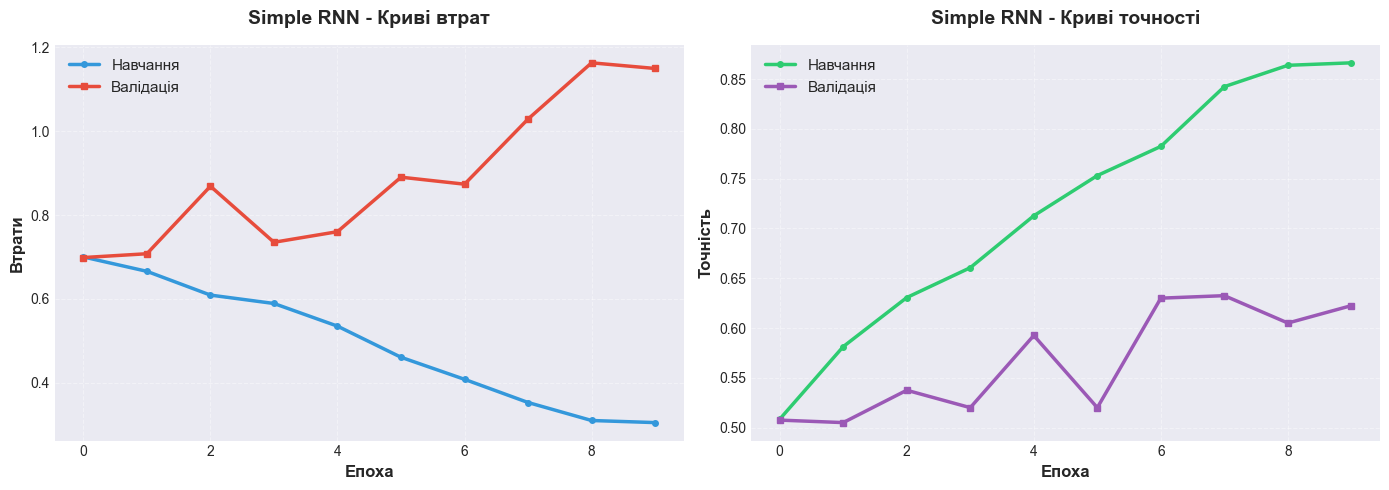


🧪 Оцінка Simple RNN на тестовому наборі...

📊 РЕЗУЛЬТАТИ ТЕСТУ - Simple RNN
│ Метрика              Значення   Оцінка              
├----------------------------------------------------------
│ Точність             0.6479     ★★★★★★              
│ Прецизійність        0.6497     ★★★★★★              
│ Повнота              0.6400     ★★★★★★              
│ F1-оцінка            0.6448     ★★★★★★              
│ ROC AUC              0.6297     ★★★★★★              


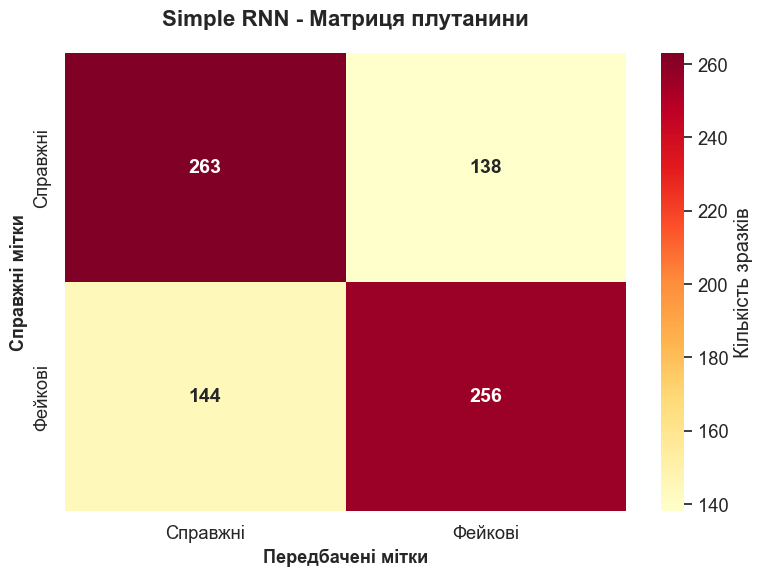

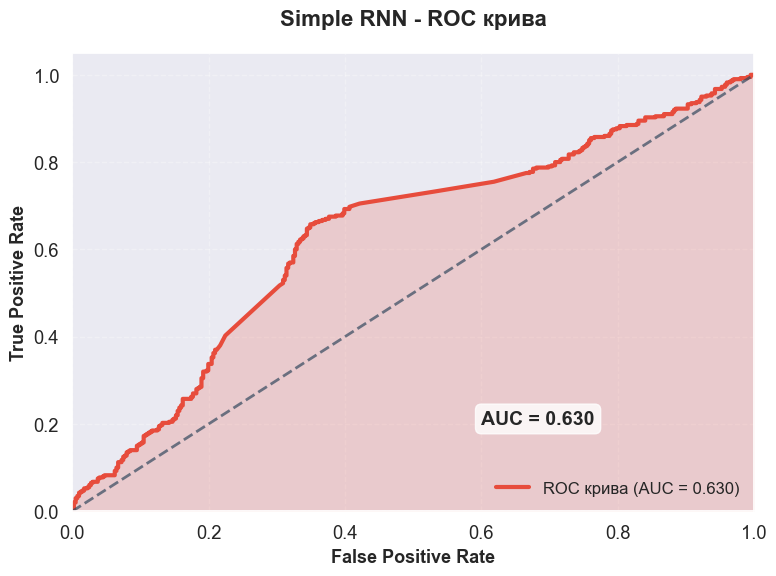


⏱️ Час навчання RNN: 46.54 секунд

🧠 ЕКСПЕРИМЕНТ З LSTM

📐 Архітектура LSTM моделі:
  ├─ Розмір ембеддингу: 100
  ├─ Прихований розмір: 128
  ├─ Кількість шарів: 2
  ├─ Бідирекційний: True
  ├─ Dropout: 0.3
  ├─ Розмір словника: 20,000
  └─ Загальна кількість параметрів: 2,631,041

🎯 Навчання LSTM на cpu...
📈 Навчання LSTM протягом 10 епох...
--------------------------------------------------------------------------------
Епоха  1/10 [22.97с] | Втрати: 0.3044 | Точність: 0.8607 | Val Втрати: 0.1405 | Val Точність: 0.9650
Епоха  2/10 [23.48с] | Втрати: 0.1398 | Точність: 0.9596 | Val Втрати: 0.0716 | Val Точність: 0.9875
Епоха  3/10 [24.24с] | Втрати: 0.0904 | Точність: 0.9728 | Val Втрати: 0.0860 | Val Точність: 0.9775
Епоха  4/10 [24.03с] | Втрати: 0.0582 | Точність: 0.9843 | Val Втрати: 0.0751 | Val Точність: 0.9825
Епоха  5/10 [23.12с] | Втрати: 0.0444 | Точність: 0.9893 | Val Втрати: 0.0516 | Val Точність: 0.9825
Епоха  6/10 [23.80с] | Втрати: 0.0874 | Точність: 0.9700 | Val Втрат

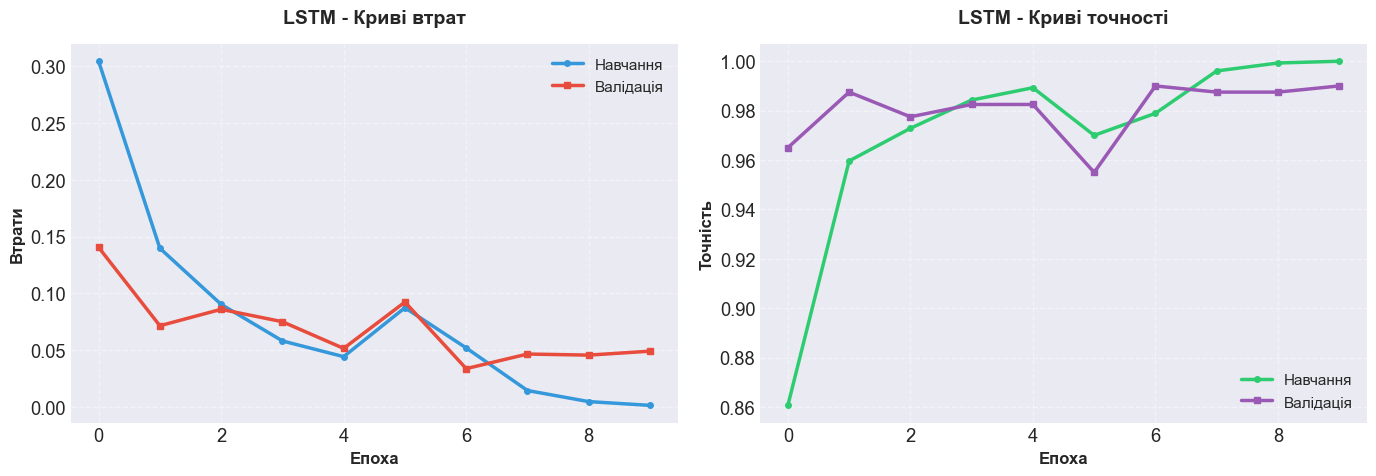


🧪 Оцінка LSTM на тестовому наборі...

📊 РЕЗУЛЬТАТИ ТЕСТУ - LSTM
│ Метрика              Значення   Оцінка              
├----------------------------------------------------------
│ Точність             0.9938     ★★★★★★★★★           
│ Прецизійність        0.9975     ★★★★★★★★★           
│ Повнота              0.9900     ★★★★★★★★★           
│ F1-оцінка            0.9937     ★★★★★★★★★           
│ ROC AUC              0.9991     ★★★★★★★★★           


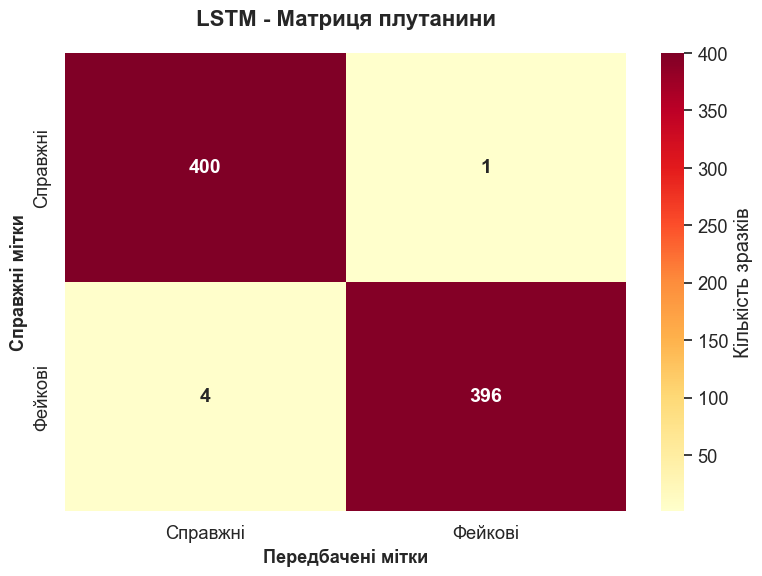

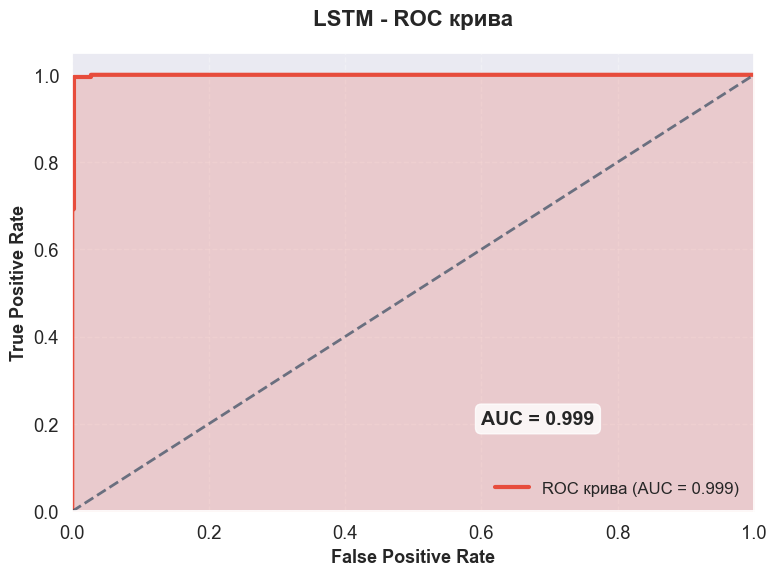


⏱️ Час навчання LSTM: 234.37 секунд

📊 ПОРІВНЯННЯ МОДЕЛЕЙ

📈 Порівняння продуктивності:
+------------------+---------+----------+
| Метрика          |     RNN |     LSTM |
+==================+=========+==========+
| Точність         |  0.6479 |   0.9938 |
+------------------+---------+----------+
| Прецизійність    |  0.6497 |   0.9975 |
+------------------+---------+----------+
| Повнота          |  0.64   |   0.99   |
+------------------+---------+----------+
| F1-оцінка        |  0.6448 |   0.9937 |
+------------------+---------+----------+
| ROC AUC          |  0.6297 |   0.9991 |
+------------------+---------+----------+
| Час навчання (с) | 46.54   | 234.37   |
+------------------+---------+----------+

📈 Аналіз покращення (LSTM vs RNN):
+---------------+----------------+-----------------+--------------+
| Метрика       |   Значення RNN |   Значення LSTM |   Покращення |
+===============+================+=================+==============+
| Точність      |       0.64794  |       

In [10]:
# комірка 10
if __name__ == "__main__":
    # Проведення експерименту з токенізацією NLTK
    print("\n" + "="*70)
    print("🚀 ЗАПУСК ЕКСПЕРИМЕНТУ З КЛАСИФІКАЦІЇ ФЕЙКОВИХ НОВИН")
    print("="*70)
    print("🎯 Порівняння Simple RNN vs LSTM з використанням токенізації")
    print("⏳ Очікуйте, процес може зайняти декілька хвилин...")
    
    results = run_experiment_with_nltk()
    
    if results is not None:
        print("\n" + "="*70)
        print("✅ ЕКСПЕРИМЕНТ УСПІШНО ЗАВЕРШЕНО!")
        print("="*70)
        
        # Збереження результатів у файли
        print("\n💾 Збереження результатів у файли...")
        
        # Збереження метрик
        metrics_df = pd.DataFrame({
            'Модель': ['RNN', 'LSTM'],
            'Точність': [results['rnn_metrics']['accuracy'], results['lstm_metrics']['accuracy']],
            'Прецизійність': [results['rnn_metrics']['precision'], results['lstm_metrics']['precision']],
            'Повнота': [results['rnn_metrics']['recall'], results['lstm_metrics']['recall']],
            'F1_оцінка': [results['rnn_metrics']['f1'], results['lstm_metrics']['f1']],
            'ROC_AUC': [results['rnn_metrics']['roc_auc'], results['lstm_metrics']['roc_auc']],
            'Параметри': [results['rnn_params'], results['lstm_params']],
            'Час_навчання_с': [results['rnn_time'], results['lstm_time']]
        })
        
        metrics_df.to_csv('fake_news_results_nltk.csv', index=False, encoding='utf-8-sig')
        print("📄 ✅ Результати збережено у 'fake_news_results_nltk.csv'")
        
        # Збереження таблиці порівняння
        results['comparison'].to_csv('model_comparison_nltk.csv', index=False, encoding='utf-8-sig')
        print("📊 ✅ Порівняння моделей збережено у 'model_comparison_nltk.csv'")
        
        # Збереження аналізу покращення
        results['improvements'].to_csv('improvement_analysis_nltk.csv', index=False, encoding='utf-8-sig')
        print("📈 ✅ Аналіз покращення збережено у 'improvement_analysis_nltk.csv'")
        
        print("\n" + "="*70)
        print("🎉 ЕКСПЕРИМЕНТ ЗАВЕРШЕНО УСПІШНО!")
        print("📊 Візуалізації згенеровано та відображено")
        print("💾 Результати збережено у файли CSV")
        print("="*70)

## Dataset overview
Використано два основних CSV-файли: 
- Fake.csv: 23.481 статей фейкових новин
- True.csv: 21.417 статей справжніх новин
Розподіл за темами: політика, світові новини, військові конфлікти.
Розподіл на набори: тренувальний, валідаційний та тестові набори.

## Рекурентні нейронні мережі (RNN)
RNN - це спеціалізований тип нейронних мереж для обробки послідовних даних, де прихований стан зберігає інформацію про попередні елементи:

**Математичні формули:**
1. **Прихований стан:** $h_t = \tanh(W_{ih} \cdot x_t + W_{hh} \cdot h_{t-1} + b_h)$
2. **Вихід:** $o = W_{ho} \cdot h_T + b_o$
3. **Імовірність:** $\hat{y} = \sigma(o)$

##  Мережі з довгостроковою короткостроковою пам'яттю (LSTM)

LSTM вирішує проблему зникаючого градієнта RNN через систему воріт, що контролює потік інформації:

**Математичні формули:**
1. **Забуваюча затворка:** $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$
2. **Вхідна затворка:** $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$
3. **Кандидат на оновлення:** $\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$
4. **Оновлення комірки:** $C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t$
5. **Вихідна затворка:** $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$
6. **Оновлення прихованого стану:** $h_t = o_t \cdot \tanh(C_t)$

## Висновки
Успішно реалізовано повний цикл дослідження з класифікації фейкових новин за допомогою нейронних мереж. Робота демонструє практичне застосування сучасних методів глибокого навчання для вирішення актуальної соціальної проблеми.
Робота демонструє, що технології штучного інтелекту можуть бути ефективним інструментом у боротьбі з дезінформацією. Розроблені моделі показують, що автоматичне виявлення фейкових новин є технічно можливим та практично реалізованим.
